# Projet CO2 - Exploration des données

## Contexte

L’objectif de ce projet est d’analyser les émissions de CO2 des véhicules commercialisés en France afin d’identifier les facteurs influençant la pollution.

## Objectif

- Comprendre la structure du jeu de données
- Identifier les variables influençant les émissions de CO2
- Mettre en évidence des tendances à l’aide de visualisations
- Préparer les données pour une future modélisation

In [23]:
print("Projet CO2")

Projet CO2


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Chargement des données 2014

Nous importons le jeu de données contenant les caractéristiques techniques des véhicules commercialisés en France en 2014.

Le fichier est encodé en `latin1` et utilise le séparateur `;`. Ces paramètres doivent être précisés lors de la lecture du fichier avec pandas.

In [25]:
df_2014 = pd.read_csv("../data/co2_2014.csv", encoding="latin1", sep=";")
df_2014.head()

,lib_mrq,lib_mod_doss,lib_mod,dscom,cnit,tvv,cod_cbr,hybride,puiss_admin_98,puiss_max,...,masse_ordma_min,masse_ordma_max,champ_v9,date_maj,Carrosserie,gamme,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29
0,ALFA-ROMEO,159,159,159 1750 Tbi (200ch),M10ALFVP000G340,939AXN1B52C,ES,non,12,147,...,1505,1505,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER,NaN,NaN,NaN,NaN
1,ALFA-ROMEO,159,159,159 1750 Tbi (200ch),M10ALFVP000H341,939BXN1B53C,ES,non,12,147,...,1555,1555,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER,NaN,NaN,NaN,NaN
2,ALFA-ROMEO,159,159,159 2.0 JTDm (136ch),M10ALFVP000E302,939AXR1B64,GO,non,7,100,...,1565,1565,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER,NaN,NaN,NaN,NaN
3,ALFA-ROMEO,159,159,159 2.0 JTDm (136ch),M10ALFVP000F303,939AXR1B64B,GO,non,7,100,...,1565,1565,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER,NaN,NaN,NaN,NaN
4,ALFA-ROMEO,159,159,159 2.0 JTDm (170ch),M10ALFVP000G304,939AXS1B66,GO,non,9,125,...,1565,1565,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER,NaN,NaN,NaN,NaN


## Aperçu des données 2014

Les premières lignes du jeu de données permettent d’observer les différentes variables disponibles, comme la marque du véhicule, le type de carburant, la puissance moteur, la masse ou encore les émissions de CO₂.

In [26]:
# Nombre de lignes et colonnes
df_2014.shape

(55044, 30)

Le jeu de données contient 55 044 lignes et 30 colonnes.

In [27]:
# Informations générales
df_2014.info()

<class 'pandas.DataFrame'>
RangeIndex: 55044 entries, 0 to 55043
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   lib_mrq            55044 non-null  str    
 1   lib_mod_doss       55044 non-null  str    
 2   lib_mod            55044 non-null  str    
 3   dscom              55044 non-null  str    
 4   cnit               55044 non-null  str    
 5   tvv                55044 non-null  str    
 6   cod_cbr            55044 non-null  str    
 7   hybride            55044 non-null  str    
 8   puiss_admin_98     55044 non-null  int64  
 9   puiss_max          55044 non-null  str    
 10  typ_boite_nb_rapp  55044 non-null  str    
 11  conso_urb          55001 non-null  str    
 12  conso_exurb        55001 non-null  str    
 13  conso_mixte        55010 non-null  str    
 14  co2                55010 non-null  float64
 15  co_typ_1           54886 non-null  str    
 16  hc                 9773 non-null 

La majorité des variables sont de type object. Certaines variables quantitatives semblent mal typées et devront être converties.

In [28]:
# Statistiques descriptives
df_2014.describe(include='all')

,lib_mrq,lib_mod_doss,lib_mod,dscom,cnit,tvv,cod_cbr,hybride,puiss_admin_98,puiss_max,...,masse_ordma_min,masse_ordma_max,champ_v9,date_maj,Carrosserie,gamme,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29
count,55044,55044,55044,55044,55044,55044,55044,55044,55044.000000,55044,...,55044.000000,55044.000000,54983,3247,55044,55044,0.0,0.0,0.0,0.0
unique,46,483,434,3837,54982,35430,13,2,NaN,232,...,NaN,NaN,35,5,11,7,NaN,NaN,NaN,NaN
top,MERCEDES,VIANO,VIANO,VIANO 2.2 CDI,M10ALFVP000K441,F142ABE,GO,non,NaN,120,...,NaN,NaN,"""715/2007*692/2008EURO5",mars-14,MINIBUS,MOY-INFER,NaN,NaN,NaN,NaN
freq,36220,14031,14031,5874,2,4,49311,54655,NaN,19968,...,NaN,NaN,23979,2810,46107,33438,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.551504,NaN,...,2102.104553,2341.021801,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.126021,NaN,...,294.731715,424.067895,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,...,825.000000,825.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.000000,NaN,...,1982.000000,2075.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.000000,NaN,...,2076.000000,2355.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.000000,NaN,...,2246.000000,2709.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Les statistiques descriptives mettent en évidence une forte diversité des véhicules et certaines colonnes à forte cardinalité.
Certaines variables contiennent un nombre important de valeurs manquantes, notamment hc, hcnox et les colonnes Unnamed.

In [29]:
df_2014.isnull().sum()

lib_mrq                  0
lib_mod_doss             0
lib_mod                  0
dscom                    0
cnit                     0
tvv                      0
cod_cbr                  0
hybride                  0
puiss_admin_98           0
puiss_max                0
typ_boite_nb_rapp        0
conso_urb               43
conso_exurb             43
conso_mixte             34
co2                     34
co_typ_1               158
hc                   45271
nox                    158
hcnox                 9888
ptcl                  2678
masse_ordma_min          0
masse_ordma_max          0
champ_v9                61
date_maj             51797
Carrosserie              0
gamme                    0
Unnamed: 26          55044
Unnamed: 27          55044
Unnamed: 28          55044
Unnamed: 29          55044
dtype: int64

## Structure des données

Le dataset 2014 contient 55 044 observations et 30 variables décrivant les caractéristiques techniques et environnementales des véhicules commercialisés en France.

Les données comprennent notamment :
- la marque et le modèle des véhicules,
- le type de carburant,
- la puissance moteur,
- la consommation,
- la masse des véhicules,
- ainsi que différentes mesures d’émissions polluantes.

Le jeu de données contient à la fois des variables catégorielles et numériques.

L’analyse exploratoire met également en évidence plusieurs variables comportant des valeurs manquantes importantes, notamment `hc`, `hcnox`, `ptcl` ainsi que les colonnes `Unnamed`, totalement vides.

Certaines variables quantitatives étaient également stockées au format `object` et ont nécessité une conversion avant les analyses.

Dans l’ensemble, le dataset apparaît exploitable pour les analyses statistiques et les visualisations portant sur les émissions de CO₂.

## Nettoyage minimal AVANT visualisations

## Supprimer les colonnes inutiles

In [30]:
df_2014 = df_2014.drop(columns=[
    'Unnamed: 26',
    'Unnamed: 27',
    'Unnamed: 28',
    'Unnamed: 29'
])

Les colonnes `Unnamed` correspondent à des colonnes vides générées lors de l’importation du fichier. Elles ne contiennent aucune information exploitable et sont donc supprimées.

## Convertir les colonnes numériques mal typées

In [31]:
colonnes_numeriques = [
    'puiss_max',
    'conso_urb',
    'conso_exurb',
    'conso_mixte',
    'hc',
    'nox',
    'hcnox',
    'ptcl'
]

for col in colonnes_numeriques:
    df_2014[col] = pd.to_numeric(df_2014[col], errors='coerce')

Certaines variables quantitatives étaient stockées au format `object`. Une conversion vers un format numérique est nécessaire afin de permettre les calculs statistiques et la création des graphiques.

## Vérifier la conversion vers les nouveaux types

In [32]:
df_2014.info()

<class 'pandas.DataFrame'>
RangeIndex: 55044 entries, 0 to 55043
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   lib_mrq            55044 non-null  str    
 1   lib_mod_doss       55044 non-null  str    
 2   lib_mod            55044 non-null  str    
 3   dscom              55044 non-null  str    
 4   cnit               55044 non-null  str    
 5   tvv                55044 non-null  str    
 6   cod_cbr            55044 non-null  str    
 7   hybride            55044 non-null  str    
 8   puiss_admin_98     55044 non-null  int64  
 9   puiss_max          54851 non-null  float64
 10  typ_boite_nb_rapp  55044 non-null  str    
 11  conso_urb          6124 non-null   float64
 12  conso_exurb        4545 non-null   float64
 13  conso_mixte        6496 non-null   float64
 14  co2                55010 non-null  float64
 15  co_typ_1           54886 non-null  str    
 16  hc                 580 non-null  

# Heatmap des valeurs manquantes

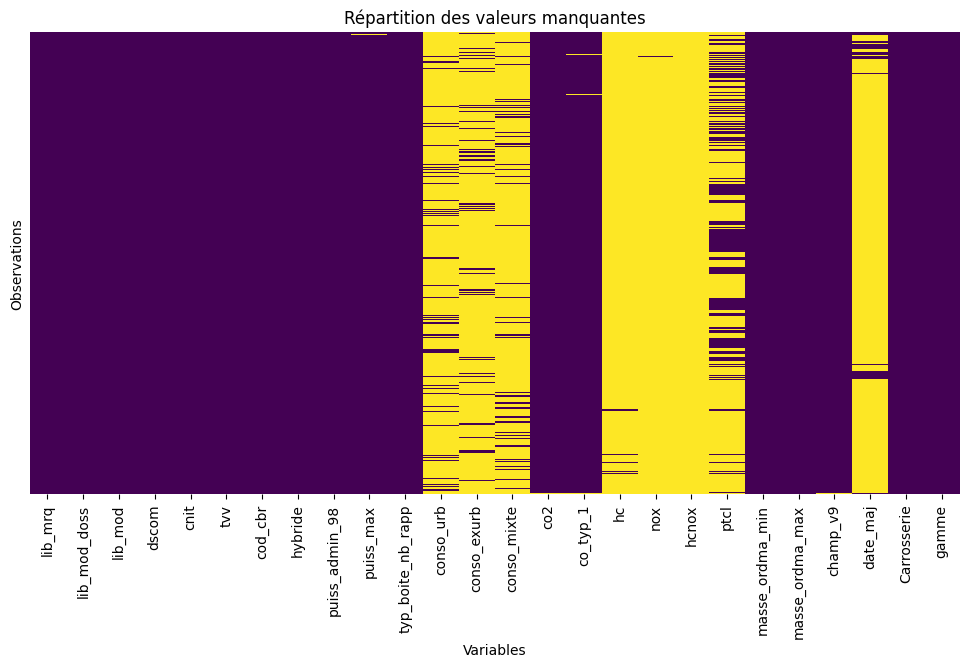

In [33]:
plt.figure(figsize=(12,6))

sns.heatmap(
    df_2014.isnull(),
    cbar=False,
    yticklabels=False,
    cmap="viridis"
)

plt.title("Répartition des valeurs manquantes")
plt.xlabel("Variables")
plt.ylabel("Observations")

plt.show()

## Observations après nettoyage

La suppression des colonnes inutiles a permis de réduire le dataset à 26 variables exploitables.

La conversion des variables quantitatives stockées au format object vers un format numérique (float64) a également mis en évidence un grand nombre de valeurs invalides ou manquantes dans certaines colonnes environnementales comme :

- hc
- nox
- hcnox
- ptcl

Ces valeurs ont été automatiquement converties en NaN grâce au paramètre `errors='coerce'`.

Les variables `hc`, `nox`, `hcnox` et `ptcl` présentent un taux extrêmement élevé de valeurs manquantes, allant d’environ 67 % à plus de 99 % des observations. Elles ont été conservées dans le cadre de l’analyse exploratoire afin d’évaluer leur qualité et leur potentiel explicatif, mais elles seront probablement exclues lors de la phase de modélisation en raison de leur faible complétude.

# Heatmap des corrélations

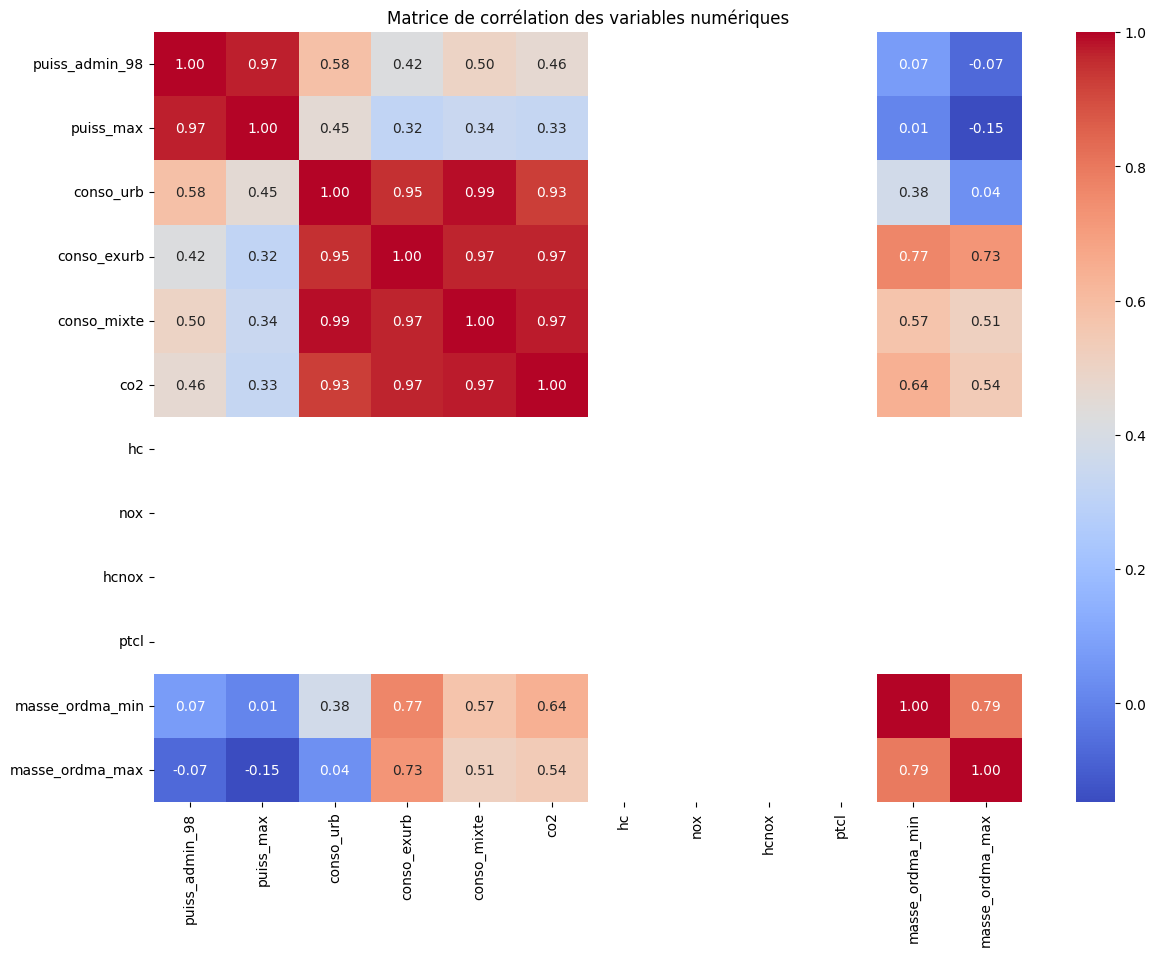

In [34]:
corr_matrix = df_2014.select_dtypes(include='number').corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Matrice de corrélation des variables numériques")

plt.show()

## Interprétation de la matrice de corrélation

La matrice de corrélation met en évidence une forte relation entre les émissions de CO₂ et les variables de consommation de carburant.

La consommation mixte (`conso_mixte`) présente la corrélation la plus élevée avec les émissions de CO₂ (0,97), suivie de la consommation extra-urbaine (`conso_exurb`, 0,97) et de la consommation urbaine (`conso_urb`, 0,93). Ce résultat est cohérent puisque les émissions de CO₂ sont directement liées à la quantité de carburant consommée par le véhicule.

La masse du véhicule apparaît également comme un facteur important. Les variables `masse_ordma_min` et `masse_ordma_max` présentent des corrélations respectives de 0,64 et 0,54 avec les émissions de CO₂. Les véhicules les plus lourds ont donc tendance à émettre davantage de CO₂.

La puissance moteur montre une corrélation plus modérée avec les émissions. La puissance administrative (`puiss_admin_98`) présente une corrélation de 0,46 tandis que la puissance maximale (`puiss_max`) atteint 0,33. Ces résultats suggèrent que la puissance influence les émissions mais dans une moindre mesure que la consommation ou la masse du véhicule.

Enfin, les variables environnementales `hc`, `nox`, `hcnox` et `ptcl` n'apparaissent pas exploitables dans cette analyse en raison du très grand nombre de valeurs manquantes, ce qui empêche le calcul de corrélations fiables.

Cette analyse permet d'identifier les variables les plus pertinentes pour la suite du projet, notamment dans les phases de prétraitement et de modélisation.

# Tableau des variables les plus corrélées au CO₂

In [35]:
co2_corr = (
    corr_matrix["co2"]
    .sort_values(ascending=False)
    .reset_index()
)

co2_corr.columns = ["Variable", "Corrélation avec CO₂"]

co2_corr

,Variable,Corrélation avec CO₂
0,co2,1.000000
1,conso_mixte,0.973868
2,conso_exurb,0.967513
3,conso_urb,0.927157
4,masse_ordma_min,0.643665
5,masse_ordma_max,0.540156
6,puiss_admin_98,0.463154
7,puiss_max,0.331356
8,hc,NaN
9,nox,NaN


## Variables non exploitables pour l'analyse des corrélations

Les variables `hc`, `nox`, `hcnox` et `ptcl` présentent des valeurs de corrélation non calculables (`NaN`).

Cette situation s'explique par la présence d'un très grand nombre de valeurs manquantes dans ces colonnes, déjà observée lors de l'analyse exploratoire.

Afin de concentrer l'analyse sur des résultats statistiquement fiables, ces variables sont retirées du tableau suivant.

In [36]:
co2_corr = (
    corr_matrix["co2"]
    .sort_values(ascending=False)
    .dropna()
    .reset_index()
)

co2_corr.columns = ["Variable", "Corrélation avec CO₂"]

co2_corr

,Variable,Corrélation avec CO₂
0,co2,1.000000
1,conso_mixte,0.973868
2,conso_exurb,0.967513
3,conso_urb,0.927157
4,masse_ordma_min,0.643665
5,masse_ordma_max,0.540156
6,puiss_admin_98,0.463154
7,puiss_max,0.331356


## Analyse des variables les plus corrélées au CO₂

Le tableau filtré confirme les observations de la matrice de corrélation. Les émissions de CO₂ sont principalement liées aux différentes mesures de consommation de carburant, en particulier la consommation mixte, extra-urbaine et urbaine.

La masse du véhicule apparaît également comme un facteur explicatif important, tandis que la puissance moteur présente une influence plus modérée.

Ces résultats permettront d'orienter la sélection des variables lors de la phase de modélisation.

# Pairplot

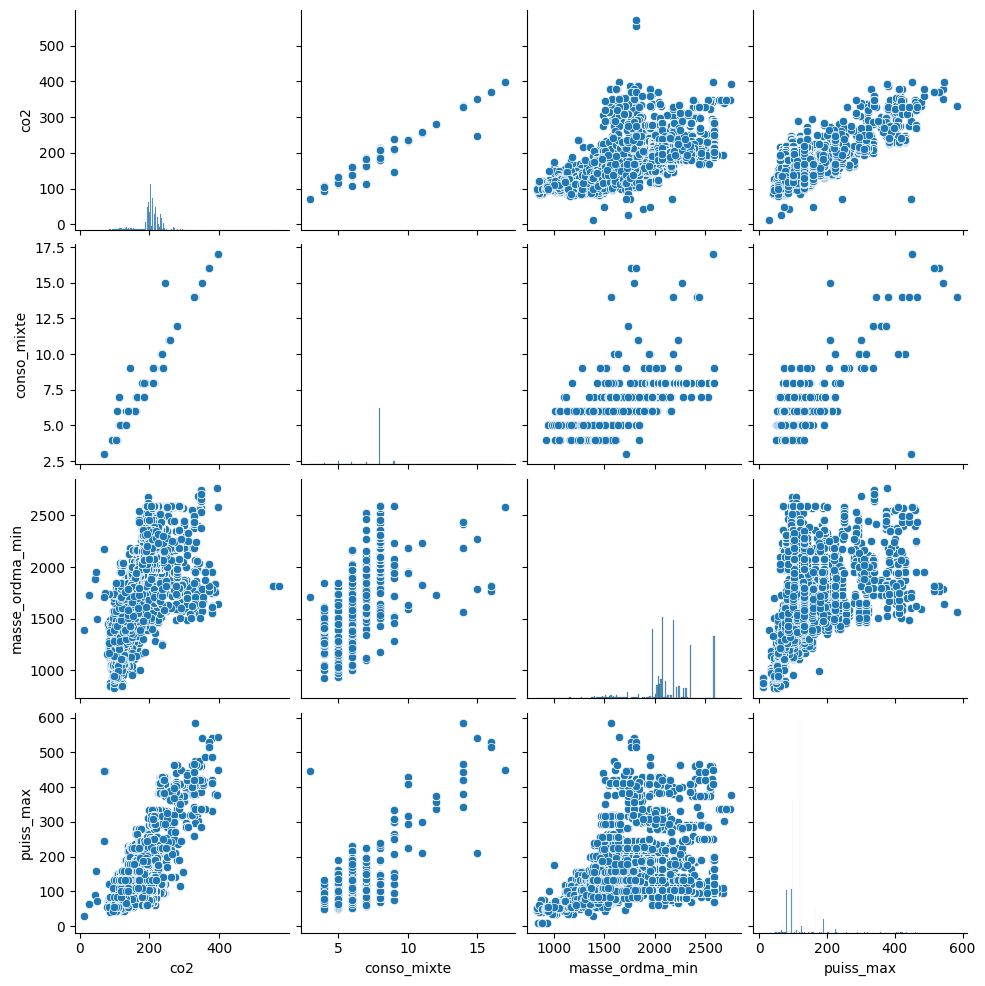

In [41]:
variables_pairplot = [
    'co2',
    'conso_mixte',
    'masse_ordma_min',
    'puiss_max'
]

sns.pairplot(
    df_2014[variables_pairplot],
    diag_kind="hist"
)

plt.show()

## Interprétation du Pairplot

Le pairplot permet d'examiner simultanément les distributions individuelles des variables ainsi que les relations entre elles.

On observe une relation très forte entre la consommation mixte (`conso_mixte`) et les émissions de CO₂ (`co2`). Les véhicules consommant davantage de carburant sont également ceux qui émettent le plus de CO₂, ce qui confirme les résultats observés dans la matrice de corrélation.

La masse du véhicule (`masse_ordma_min`) présente également une relation positive avec les émissions de CO₂. Les véhicules les plus lourds tendent à être plus polluants, même si cette relation est moins marquée que celle observée avec la consommation.

La puissance maximale du moteur (`puiss_max`) est elle aussi positivement liée aux émissions de CO₂. Les véhicules les plus puissants affichent globalement des niveaux d'émissions plus élevés, ce qui traduit l'impact de la motorisation sur la consommation et les rejets de CO₂.

Les distributions visibles sur la diagonale montrent que certaines variables sont concentrées autour de plages de valeurs spécifiques, reflétant la prédominance de certaines catégories de véhicules dans le dataset.

Dans l'ensemble, ce pairplot confirme que la consommation, la masse et la puissance du moteur constituent des facteurs fortement associés aux émissions de CO₂. Ces variables apparaissent comme des candidates pertinentes pour les futures étapes de modélisation.

## Data visualisation

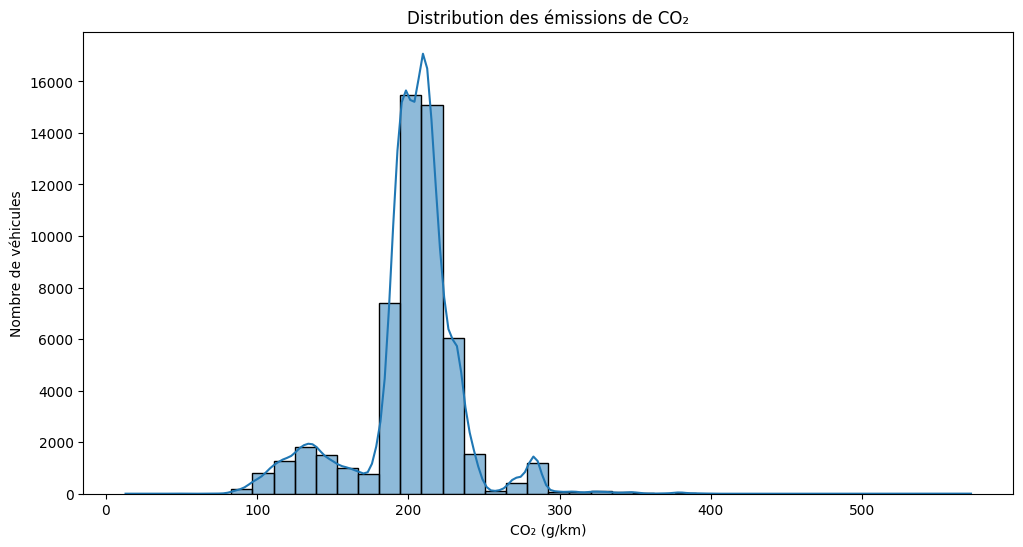

In [43]:
plt.figure(figsize=(12,6))

sns.histplot(df_2014['co2'], bins=40, kde=True)

plt.title("Distribution des émissions de CO₂")
plt.xlabel("CO₂ (g/km)")
plt.ylabel("Nombre de véhicules")

plt.show()

## Analyse de la distribution des émissions de CO₂

La distribution des émissions de CO₂ des véhicules commercialisés en France en 2014 montre une forte concentration des véhicules entre 180 et 230 g/km.

La distribution présente une asymétrie vers la droite, traduisant la présence de véhicules fortement émetteurs. Quelques valeurs extrêmes dépassent 300 g/km.

On observe également plusieurs pics dans la distribution, ce qui peut s’expliquer par :

différents types de motorisations,
différentes catégories de véhicules,
ou encore des différences de carburants.

La majorité des véhicules reste néanmoins regroupée autour des valeurs moyennes d’émission.

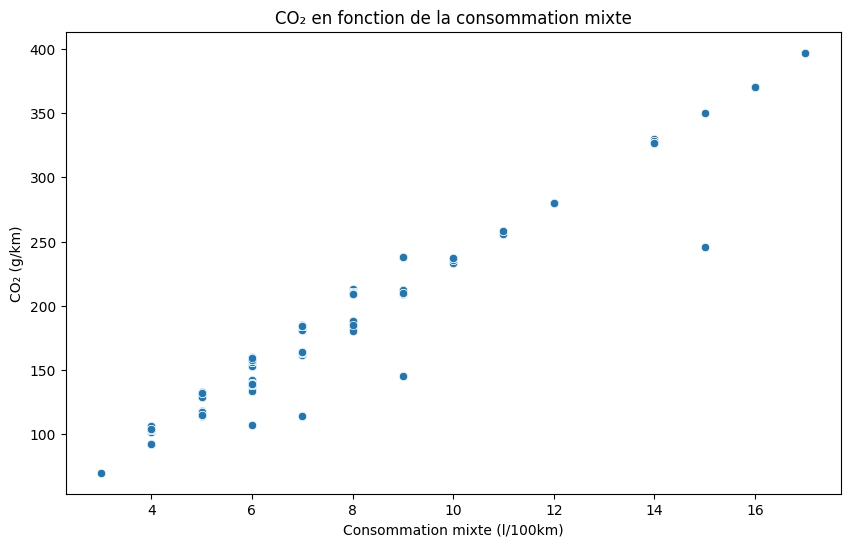

In [44]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='conso_mixte',
    y='co2',
    data=df_2014
)

plt.title("CO₂ en fonction de la consommation mixte")
plt.xlabel("Consommation mixte (l/100km)")
plt.ylabel("CO₂ (g/km)")

plt.show()

## Analyse du CO₂ en fonction de la consommation mixte

Le graphique met en évidence une relation positive très marquée entre la consommation mixte des véhicules et leurs émissions de CO₂.

Plus la consommation de carburant augmente, plus les émissions de CO₂ augmentent également. Les points sont fortement alignés, ce qui traduit une relation quasi linéaire entre les deux variables.

Les véhicules les plus consommateurs, au-delà de 12 l/100 km, présentent logiquement les niveaux d’émissions les plus élevés.

Cette observation confirme que la consommation mixte constitue l’un des principaux facteurs explicatifs des émissions de CO₂ dans le dataset.

## Validation statistique

In [45]:
df_2014[['conso_mixte', 'co2']].corr()

,conso_mixte,co2
conso_mixte,1.000000,0.973868
co2,0.973868,1.000000


La corrélation calculée entre la consommation mixte et les émissions de CO₂ est très élevée (0,97), ce qui confirme quantitativement la forte relation observée sur le graphique.

Cette corrélation proche de 1 indique que les véhicules consommant davantage de carburant sont également ceux qui émettent le plus de CO₂.

La consommation mixte apparaît ainsi comme l’une des variables les plus explicatives des émissions polluantes dans ce jeu de données.

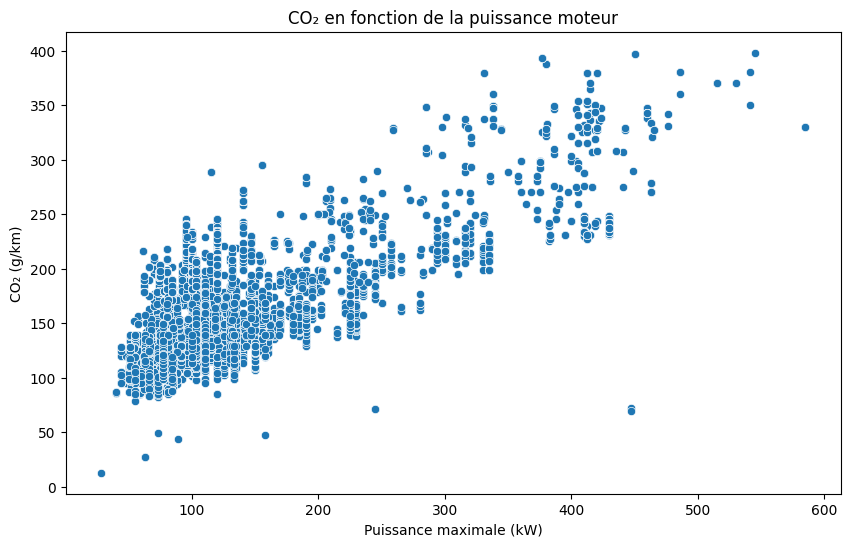

In [46]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='puiss_max',
    y='co2',
    data=df_2014
)

plt.title("CO₂ en fonction de la puissance moteur")
plt.xlabel("Puissance maximale (kW)")
plt.ylabel("CO₂ (g/km)")

plt.show()

## Analyse du CO₂ en fonction de la puissance moteur

Le graphique met en évidence une relation positive entre la puissance moteur et les émissions de CO₂.

Globalement, les véhicules les plus puissants tendent à produire davantage d’émissions polluantes. Cette tendance apparaît clairement avec l’augmentation progressive des valeurs de CO₂ lorsque la puissance maximale augmente.

Cependant, la dispersion des points reste plus importante que pour la consommation mixte, ce qui indique que la puissance moteur n’explique pas à elle seule les émissions de CO₂.

D’autres facteurs, comme :

la masse du véhicule,
le type de carburant,
ou encore la consommation,

semblent également jouer un rôle important dans les niveaux d’émissions observés.

## Validation statistique

In [47]:
df_2014[['puiss_max', 'co2']].corr()

,puiss_max,co2
puiss_max,1.000000,0.331356
co2,0.331356,1.000000


La corrélation calculée entre la puissance moteur et les émissions de CO₂ est positive mais modérée (0,33).

Ce résultat confirme la tendance observée graphiquement : les véhicules les plus puissants ont globalement tendance à émettre davantage de CO₂.

Cependant, cette corrélation reste nettement plus faible que celle observée avec la consommation mixte, ce qui montre que la puissance moteur n’est pas le facteur principal expliquant les émissions polluantes.

Les émissions de CO₂ dépendent donc également d’autres caractéristiques du véhicule, comme la consommation, la masse ou le type de carburant.

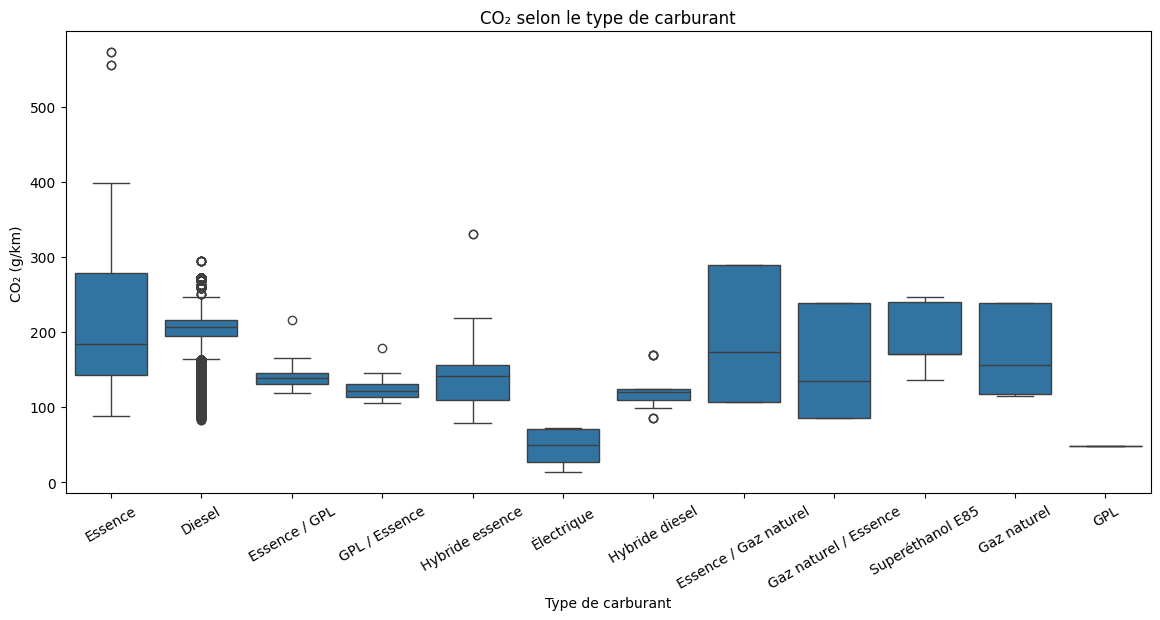

In [48]:
carburants = {
    'ES': 'Essence',
    'GO': 'Diesel',
    'EE': 'Électrique',
    'EH': 'Hybride essence',
    'GH': 'Hybride diesel',
    'ES/GN': 'Essence / Gaz naturel',
    'GN/ES': 'Gaz naturel / Essence',
    'FE': 'Superéthanol E85',
    'GN': 'Gaz naturel',
    'GL': 'GPL',
    'GP/ES': 'GPL / Essence',
    'ES/GP': 'Essence / GPL'
}
df_2014['carburant_libelle'] = df_2014['cod_cbr'].map(carburants)

plt.figure(figsize=(14,6))

sns.boxplot(
    x='carburant_libelle',
    y='co2',
    data=df_2014
)

plt.xticks(rotation=30)

plt.title("CO₂ selon le type de carburant")
plt.xlabel("Type de carburant")
plt.ylabel("CO₂ (g/km)")

plt.show()

## Analyse du CO₂ selon le type de carburant

Ce graphique met en évidence des différences importantes d’émissions de CO₂ selon le type de carburant utilisé par les véhicules.

Les véhicules utilisant certains carburants présentent des émissions médianes plus élevées ainsi qu’une plus forte dispersion des valeurs. À l’inverse, certaines motorisations affichent des niveaux d’émissions plus faibles et plus homogènes.

Le carburant `ES` présente notamment une forte variabilité ainsi que plusieurs valeurs extrêmes dépassant les 500 g/km, correspondant probablement à des véhicules très puissants ou sportifs.

Les carburants hybrides ou alternatifs affichent globalement des émissions plus faibles.

Cette analyse confirme que le type de carburant constitue un facteur explicatif important des émissions de CO₂.

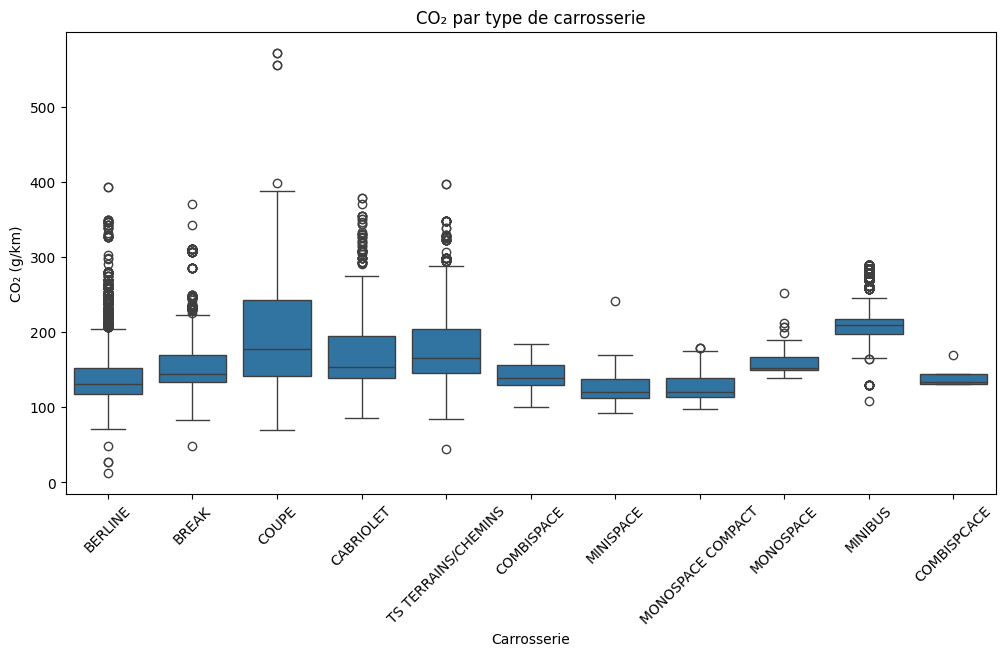

In [49]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x='Carrosserie',
    y='co2',
    data=df_2014
)

plt.xticks(rotation=45)

plt.title("CO₂ par type de carrosserie")
plt.xlabel("Carrosserie")
plt.ylabel("CO₂ (g/km)")

plt.show()

## Analyse du CO₂ par type de carrosserie

Le graphique met en évidence des différences d’émissions de CO₂ selon les types de carrosserie des véhicules.

Les véhicules de type :
- `COUPE`,
- `MINIBUS`,
- et certains `TS TERRAINS/CHEMINS`

présentent globalement les niveaux d’émissions les plus élevés ainsi qu’une forte dispersion des valeurs.

À l’inverse, les véhicules de type :
- `MINISPACE`,
- `MONOSPACE COMPACT`,
- ou `COMBISPACE`

affichent des émissions plus faibles et plus homogènes.

La présence de nombreux points atypiques (outliers) montre également que certains modèles particuliers émettent des quantités de CO₂ nettement supérieures à la moyenne de leur catégorie.

Cette analyse suggère que le type de carrosserie influence les émissions polluantes, probablement en lien avec la taille, la masse et la puissance des véhicules.

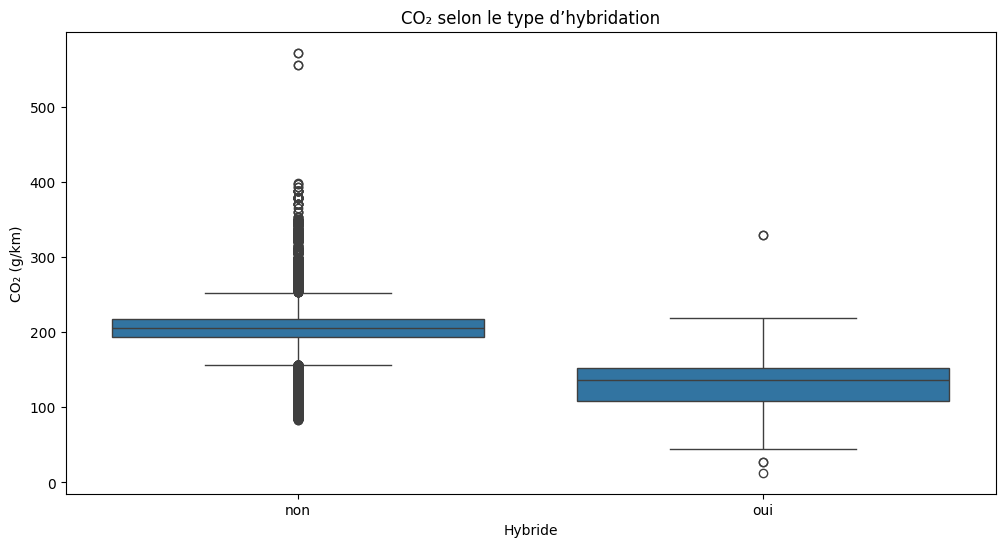

In [50]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x='hybride',
    y='co2',
    data=df_2014
)

plt.title("CO₂ selon le type d’hybridation")
plt.xlabel("Hybride")
plt.ylabel("CO₂ (g/km)")

plt.show()

## Analyse du CO₂ selon le type d’hybridation

Le graphique compare les émissions de CO₂ entre les véhicules hybrides et non hybrides.

Les véhicules hybrides (`oui`) présentent globalement des émissions de CO₂ plus faibles que les véhicules non hybrides (`non`).

La médiane des émissions est nettement inférieure pour les véhicules hybrides, ce qui suggère un impact positif de l’hybridation sur la réduction des émissions polluantes.

Les véhicules non hybrides affichent également une plus grande dispersion des valeurs ainsi qu’un nombre important de valeurs extrêmes, avec certains modèles dépassant largement les 300 g/km de CO₂.

Cette analyse met en évidence l’intérêt des technologies hybrides dans la diminution des émissions de CO₂ des véhicules commercialisés en 2014.

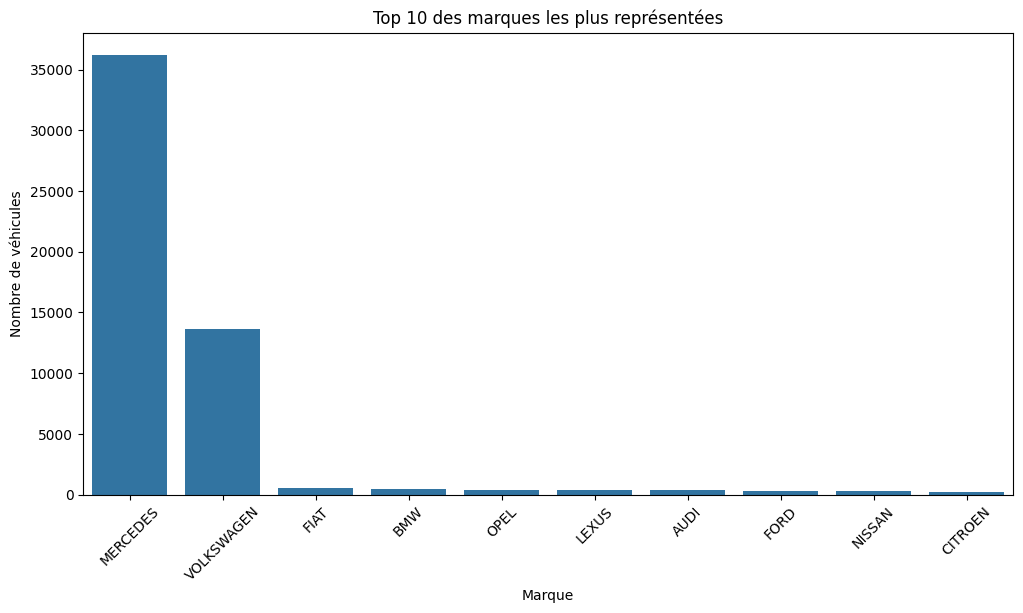

In [51]:
# Top 10 des marques les plus représentées

top_marques_rep = (
    df_2014['lib_mrq']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_marques_rep.index,
    y=top_marques_rep.values
)

plt.xticks(rotation=45)
plt.title("Top 10 des marques les plus représentées")
plt.xlabel("Marque")
plt.ylabel("Nombre de véhicules")

plt.show()

# Analyse des marques les plus représentées

Le graphique met en évidence une forte concentration du jeu de données autour des marques Mercedes et Volkswagen.

Mercedes représente à elle seule plus de 36 000 observations, tandis que Volkswagen dépasse 13 000 observations. Les autres marques apparaissent dans des proportions nettement plus faibles.

Cette répartition peut s'expliquer par le fait que certaines marques disposent d'un nombre important de modèles et de déclinaisons techniques référencés dans la base de données.

Il convient donc de rappeler que ce classement reflète la représentation des véhicules dans le dataset et non nécessairement leur part réelle dans le parc automobile français.

La comparaison avec le classement des marques les plus polluantes montre également que les marques les plus présentes ne sont pas forcément celles qui affichent les émissions moyennes de CO₂ les plus élevées.

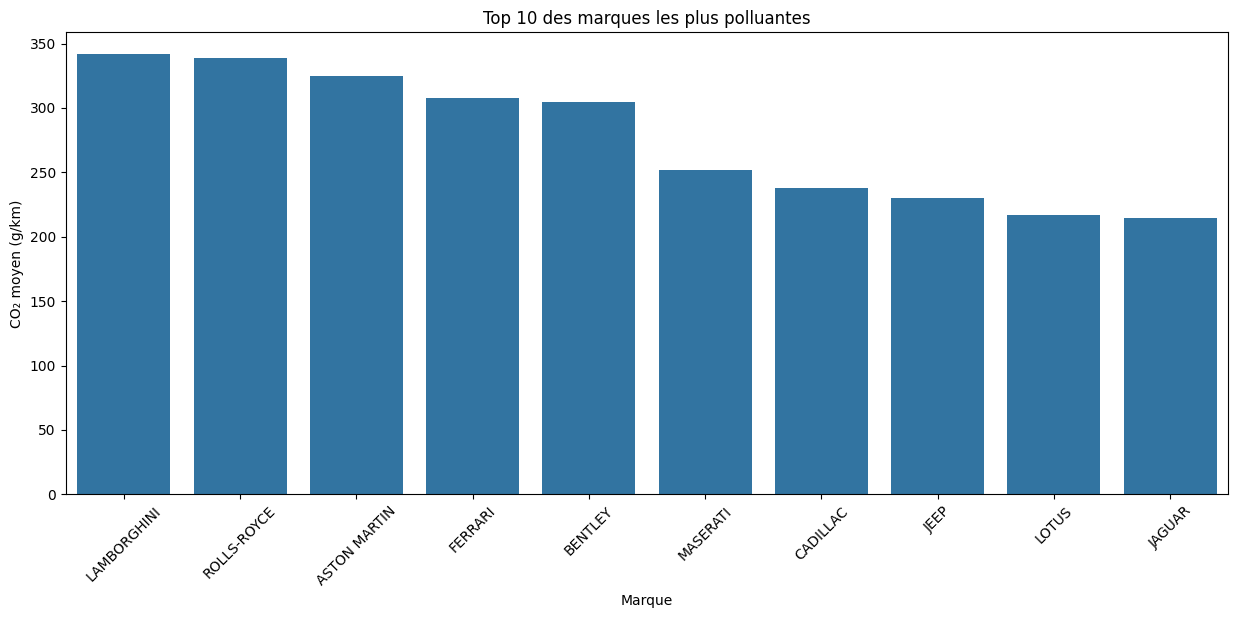

In [52]:
top_marques = (
    df_2014.groupby('lib_mrq')['co2']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(15,6))

sns.barplot(
    x=top_marques.index,
    y=top_marques.values
)

plt.xticks(rotation=45)

plt.title("Top 10 des marques les plus polluantes")
plt.xlabel("Marque")
plt.ylabel("CO₂ moyen (g/km)")

plt.show()

## Analyse des marques les plus polluantes

Le graphique présente les dix marques affichant les émissions moyennes de CO₂ les plus élevées dans le jeu de données.

Les premières positions sont occupées par Lamborghini, Rolls-Royce, Aston Martin, Ferrari et Bentley, des constructeurs principalement spécialisés dans les véhicules sportifs, luxueux ou de très forte puissance.

Ces résultats sont cohérents avec les caractéristiques de ces véhicules, généralement plus lourds, plus puissants et plus consommateurs de carburant.

Cette analyse met en évidence le lien entre performances automobiles et niveau moyen d'émissions de CO₂.

# Comparaison entre présence et niveau d'émissions

Les marques les plus polluantes (Lamborghini, Rolls-Royce, Ferrari...) ne figurent pas parmi les marques les plus représentées du dataset.

À l'inverse, Mercedes et Volkswagen dominent largement en nombre d'observations tout en n'apparaissant pas dans le classement des émissions moyennes les plus élevées.

Cela montre que la fréquence de présence d'une marque et son niveau moyen d'émissions constituent deux dimensions distinctes qu'il convient d'analyser séparément.

Bien que certaines marques de prestige affichent des émissions très élevées, leur faible représentation limite probablement leur contribution globale aux émissions du parc automobile.

## Chargement des données 2015

Nous importons le jeu de données contenant les caractéristiques techniques des véhicules commercialisés en France en 2015.

Le fichier est encodé en `latin1` et utilise le séparateur `;`. Ces paramètres doivent être précisés lors de la lecture du fichier avec pandas.

In [53]:
df_2015 = pd.read_csv("../data/co2_2015.csv", encoding="latin1", sep=";")
df_2015.head()

,lib_mrq_doss,lib_mod_doss,mrq_utac,mod_utac,dscom,cnit,tvv,energ,hybride,puiss_admin,...,co2_mixte,co_typ_1,hc,nox,hcnox,ptcl,masse_ordma_min,masse_ordma_max,champ_v9,date_maj
0,ALFA ROMEO,159,ALFA ROMEO,159,159 1750 Tbi (200ch),M10ALFVP000G340,939AXN1B52C,ES,non,12,...,182.0,0.647,0.052,0.032,NaN,0.002,1505,1505,715/2007*692/2008EURO5,juin-14
1,ALFA ROMEO,159,ALFA ROMEO,159,159 2.0 JTDm (170ch) ECO,M10ALFVP000U221,939AXP1B54C,GO,non,9,...,136.0,0.192,NaN,0.169,0.190,0.003,1565,1565,715/2007*692/2008EURO5,juin-14
2,ALFA ROMEO,159,ALFA ROMEO,159,159 2.0 JTDm (136ch),M10ALFVP000E302,939AXR1B64,GO,non,7,...,134.0,0.066,NaN,0.149,0.175,0.001,1565,1565,715/2007*692/2008EURO5,juin-14
3,ALFA ROMEO,159,ALFA ROMEO,159,159 2.0 JTDm (136ch),M10ALFVP000F303,939AXR1B64B,GO,non,7,...,134.0,0.066,NaN,0.149,0.175,0.001,1565,1565,715/2007*692/2008EURO5,juin-14
4,ALFA ROMEO,159,ALFA ROMEO,159,159 2.0 JTDm (170ch),M10ALFVP000G304,939AXS1B66,GO,non,9,...,139.0,0.060,NaN,0.164,0.193,0.001,1565,1565,715/2007*692/2008EURO5,juin-14


# Aperçu des données 2015

Les premières lignes du jeu de données permettent d’observer les différentes variables disponibles, comme la marque du véhicule, le type de carburant, la puissance moteur, la masse ou encore les émissions de CO₂.

In [54]:
# Nombre de lignes et colonnes
df_2015.shape

(20880, 26)

Le jeu de données contient 20 880 lignes et 26 colonnes.

In [55]:
# Informations générales
df_2015.info()

<class 'pandas.DataFrame'>
RangeIndex: 20880 entries, 0 to 20879
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   lib_mrq_doss       20880 non-null  str    
 1   lib_mod_doss       20880 non-null  str    
 2   mrq_utac           20880 non-null  str    
 3   mod_utac           20880 non-null  str    
 4   dscom              20880 non-null  str    
 5   cnit               20880 non-null  str    
 6   tvv                20880 non-null  str    
 7   energ              20880 non-null  str    
 8   hybride            20880 non-null  str    
 9   puiss_admin        20880 non-null  int64  
 10  puiss_max          20824 non-null  float64
 11  puiss_heure        895 non-null    float64
 12  typ_boite_nb_rapp  20880 non-null  str    
 13  conso_urb_93       20759 non-null  float64
 14  conso_exurb        20759 non-null  float64
 15  conso_mixte        20824 non-null  float64
 16  co2_mixte          20824 non-null

La majorité des variables sont de type object. Certaines variables quantitatives semblent mal typées et devront être converties.

In [56]:
# Statistiques descriptives
df_2015.describe(include='all')

,lib_mrq_doss,lib_mod_doss,mrq_utac,mod_utac,dscom,cnit,tvv,energ,hybride,puiss_admin,...,co2_mixte,co_typ_1,hc,nox,hcnox,ptcl,masse_ordma_min,masse_ordma_max,champ_v9,date_maj
count,20880,20880,20880,20880,20880,20880,20880,20880,20880,20880.000000,...,20824.000000,20605.000000,8897.000000,20605.000000,11735.000000,19170.000000,20880.000000,20880.000000,20880,20880
unique,46,442,43,425,4111,20819,18467,13,2,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15,4
top,MERCEDES BENZ,CLASSE E,MERCEDES,SPRINTER,V 200 CDI (136ch),M10ALFVP000K441,F142ABE,GO,non,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,715/2007*136/2014EURO6,mars-15
freq,13837,3104,14120,2697,336,2,8,12675,19857,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10003,19940
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.390134,...,154.584326,0.256855,0.042104,0.093032,0.142602,0.000699,1810.563649,1846.491140,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.751439,...,44.247481,0.119007,0.012890,0.085165,0.072383,0.000958,371.924329,429.122546,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,...,13.000000,0.000000,0.000000,0.000000,0.000000,0.000000,875.000000,875.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.000000,...,122.000000,0.177000,0.033000,0.030000,0.077000,0.000000,1505.000000,1505.750000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.000000,...,147.000000,0.249000,0.042000,0.056000,0.117000,0.000000,1760.000000,1760.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.000000,...,180.000000,0.308000,0.051000,0.160000,0.213000,0.001000,2050.000000,2050.000000,NaN,NaN


Les statistiques descriptives mettent en évidence une forte diversité des véhicules présents dans le dataset ainsi que plusieurs colonnes à forte cardinalité. Certaines variables contiennent un nombre important de valeurs manquantes, notamment `puiss_heure`, `hc`, `hcnox` et `ptcl`.

In [57]:
df_2015.isnull().sum()

lib_mrq_doss             0
lib_mod_doss             0
mrq_utac                 0
mod_utac                 0
dscom                    0
cnit                     0
tvv                      0
energ                    0
hybride                  0
puiss_admin              0
puiss_max               56
puiss_heure          19985
typ_boite_nb_rapp        0
conso_urb_93           121
conso_exurb            121
conso_mixte             56
co2_mixte               56
co_typ_1               275
hc                   11983
nox                    275
hcnox                 9145
ptcl                  1710
masse_ordma_min          0
masse_ordma_max          0
champ_v9                 0
date_maj                 0
dtype: int64

## Structure des données

Le dataset 2015 contient 20 880 observations et 26 variables décrivant les caractéristiques techniques et environnementales des véhicules commercialisés en France.

Les données comprennent notamment :
- la marque et le modèle des véhicules,
- le type de carburant,
- la puissance moteur,
- la consommation,
- la masse des véhicules,
- ainsi que différentes mesures d’émissions polluantes.

Le jeu de données contient à la fois des variables catégorielles et numériques.

L’analyse exploratoire met également en évidence plusieurs variables comportant des valeurs manquantes importantes, notamment `puiss_heure`, `hc`, `hcnox` et `ptcl`.

Dans l’ensemble, le dataset apparaît exploitable pour les analyses statistiques et les visualisations portant sur les émissions de CO₂.

## Nettoyage minimal AVANT visualisations

## Supprimer les colonnes inutiles

In [62]:
colonnes_inutiles = [
    'Unnamed: 26',
    'Unnamed: 27',
    'Unnamed: 28',
    'Unnamed: 29'
]

df_2015 = df_2015.drop(
    columns=[col for col in colonnes_inutiles if col in df_2015.columns],
    errors='ignore'
)

Les colonnes `Unnamed` correspondent à des colonnes vides générées lors de l’importation du fichier. Elles ne contiennent aucune information exploitable et sont donc supprimées.

## Conversion des colonnes numériques

In [63]:
colonnes_numeriques = [
    'puiss_max',
    'conso_urb_93',
    'conso_exurb',
    'conso_mixte',
    'co2_mixte',
    'co_typ_1',
    'hc',
    'nox',
    'hcnox',
    'ptcl'
]

for col in colonnes_numeriques:
    df_2015[col] = pd.to_numeric(df_2015[col], errors='coerce')

Certaines variables quantitatives étaient stockées au format `object`. Une conversion vers un format numérique est nécessaire afin de permettre les calculs statistiques et la création des graphiques.

## Vérifier la conversion vers les nouveaux types

In [60]:
df_2015.info()

<class 'pandas.DataFrame'>
RangeIndex: 20880 entries, 0 to 20879
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   lib_mrq_doss       20880 non-null  str    
 1   lib_mod_doss       20880 non-null  str    
 2   mrq_utac           20880 non-null  str    
 3   mod_utac           20880 non-null  str    
 4   dscom              20880 non-null  str    
 5   cnit               20880 non-null  str    
 6   tvv                20880 non-null  str    
 7   energ              20880 non-null  str    
 8   hybride            20880 non-null  str    
 9   puiss_admin        20880 non-null  int64  
 10  puiss_max          20824 non-null  float64
 11  puiss_heure        895 non-null    float64
 12  typ_boite_nb_rapp  20880 non-null  str    
 13  conso_urb_93       20759 non-null  float64
 14  conso_exurb        20759 non-null  float64
 15  conso_mixte        20824 non-null  float64
 16  co2_mixte          20824 non-null

## Heatmap des valeurs manquantes

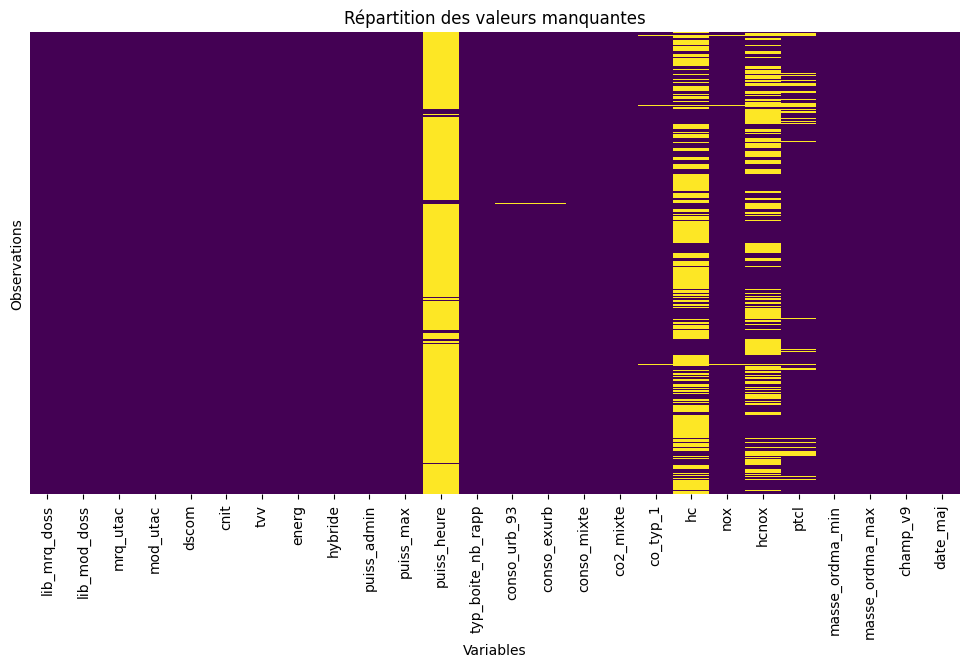

In [61]:
plt.figure(figsize=(12,6))

sns.heatmap(
    df_2015.isnull(),
    cbar=False,
    yticklabels=False,
    cmap="viridis"
)

plt.title("Répartition des valeurs manquantes")
plt.xlabel("Variables")
plt.ylabel("Observations")

plt.show()

## Analyse des valeurs manquantes

La visualisation des valeurs manquantes met en évidence plusieurs colonnes présentant des données incomplètes.

Les variables `puiss_heure`, `hc`, `hcnox` et `ptcl` concentrent la majorité des valeurs manquantes du dataset. La variable `puiss_heure` apparaît particulièrement incomplète, tandis que les variables environnementales `hc`, `hcnox` et `ptcl` présentent également un taux élevé de données absentes.

À l'inverse, la plupart des autres variables sont quasiment complètes, ce qui constitue un point positif pour les analyses statistiques et la modélisation.


## Heatmap des corrélations

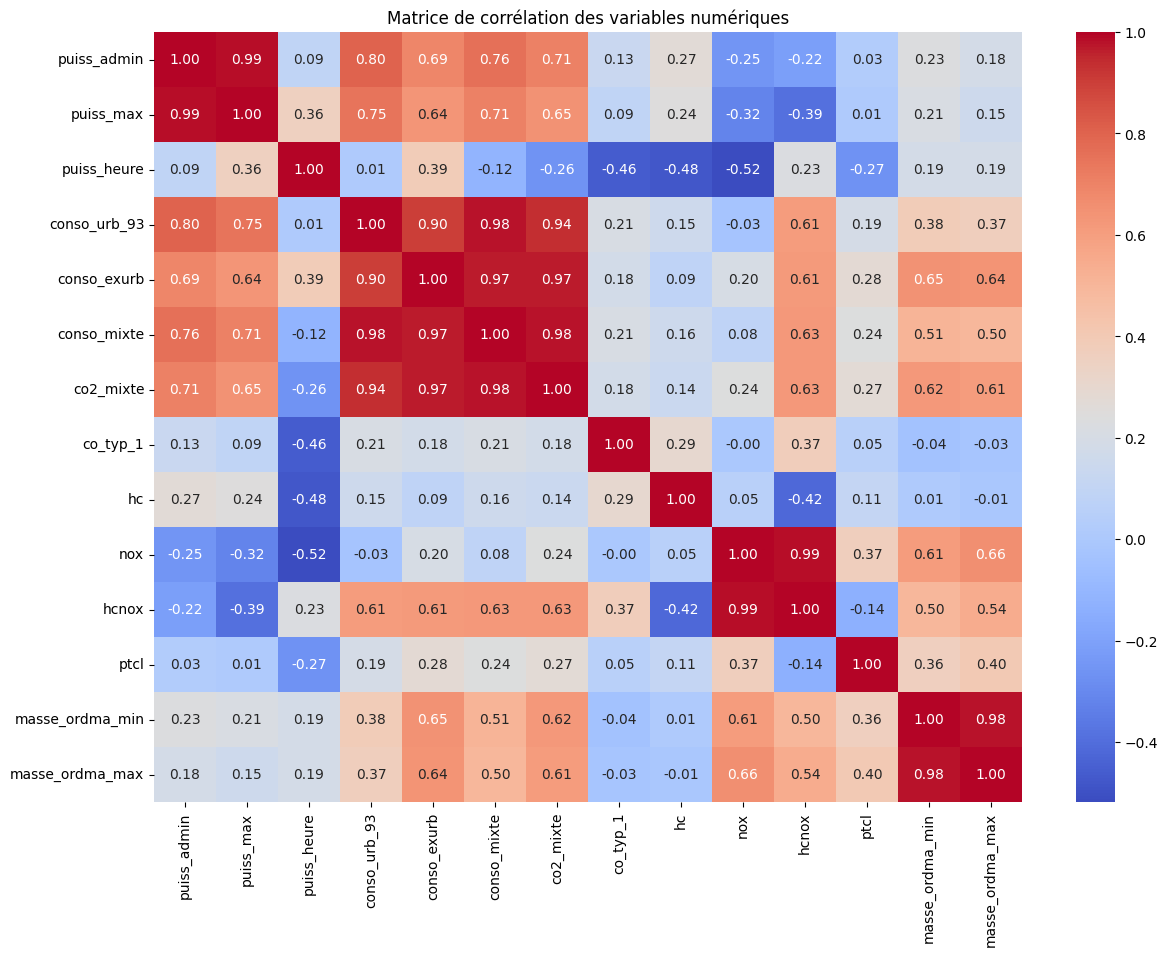

In [64]:
corr_matrix = df_2015.select_dtypes(include='number').corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Matrice de corrélation des variables numériques")

plt.show()

## Interprétation de la matrice de corrélation

La matrice de corrélation met en évidence une forte relation entre les émissions de CO₂ et les variables de consommation de carburant.

La consommation mixte (`conso_mixte`) présente la corrélation la plus élevée avec les émissions de CO₂ (`co2_mixte`) avec un coefficient de 0,98. Les consommations extra-urbaine (`conso_exurb`, 0,97) et urbaine (`conso_urb_93`, 0,94) sont également très fortement corrélées aux émissions. Ces résultats confirment que les émissions de CO₂ sont directement liées à la quantité de carburant consommée par le véhicule.

La puissance du moteur apparaît également comme un facteur important. La puissance administrative (`puiss_admin`) présente une corrélation de 0,71 avec les émissions de CO₂, tandis que la puissance maximale (`puiss_max`) atteint 0,65. Cette relation est plus marquée qu'en 2014, ce qui suggère que les véhicules les plus puissants sont généralement plus émetteurs.

La masse du véhicule joue également un rôle significatif. Les variables `masse_ordma_min` et `masse_ordma_max` présentent des corrélations respectives de 0,62 et 0,61 avec les émissions de CO₂. Les véhicules les plus lourds tendent donc à produire davantage d'émissions.

Les variables environnementales (`hc`, `nox`, `hcnox` et `ptcl`) montrent certaines corrélations avec les émissions, mais leur interprétation doit rester prudente en raison du nombre important de valeurs manquantes observé dans ces colonnes.

Cette analyse confirme que la consommation, la puissance et la masse du véhicule constituent les variables les plus pertinentes pour expliquer les émissions de CO₂ et apparaissent comme des candidates privilégiées pour les futures étapes de modélisation.

## Tableau des variables les plus corrélées au CO₂

In [65]:
co2_corr = (
    corr_matrix["co2_mixte"]
    .sort_values(ascending=False)
    .reset_index()
)

co2_corr.columns = ["Variable", "Corrélation avec CO₂"]

co2_corr

,Variable,Corrélation avec CO₂
0,co2_mixte,1.000000
1,conso_mixte,0.976291
2,conso_exurb,0.969068
3,conso_urb_93,0.936572
4,puiss_admin,0.707758
5,puiss_max,0.646613
6,hcnox,0.625951
7,masse_ordma_min,0.624973
8,masse_ordma_max,0.614277
9,ptcl,0.274536


## Variables les plus corrélées aux émissions de CO₂

Le tableau met en évidence les variables présentant les corrélations les plus fortes avec les émissions de CO₂ (`co2_mixte`).

Sans surprise, les variables de consommation de carburant sont les plus fortement corrélées aux émissions. La consommation mixte (`conso_mixte`) présente la corrélation la plus élevée (0,98), suivie de la consommation extra-urbaine (`conso_exurb`, 0,97) et de la consommation urbaine (`conso_urb_93`, 0,94).

La puissance du véhicule (`puiss_admin` et `puiss_max`) ainsi que sa masse (`masse_ordma_min` et `masse_ordma_max`) affichent également des corrélations positives importantes avec les émissions de CO₂, confirmant leur influence sur la consommation énergétique et le niveau de pollution.

Les variables environnementales (`hcnox`, `ptcl`, `nox` et `hc`) présentent des corrélations plus faibles ou modérées avec les émissions de CO₂. Leur pouvoir explicatif apparaît donc plus limité dans le cadre de cette analyse.

Ce classement confirme que la consommation, la puissance et la masse du véhicule constituent les variables les plus pertinentes pour expliquer les émissions de CO₂ dans le dataset 2015.

## Pairplot

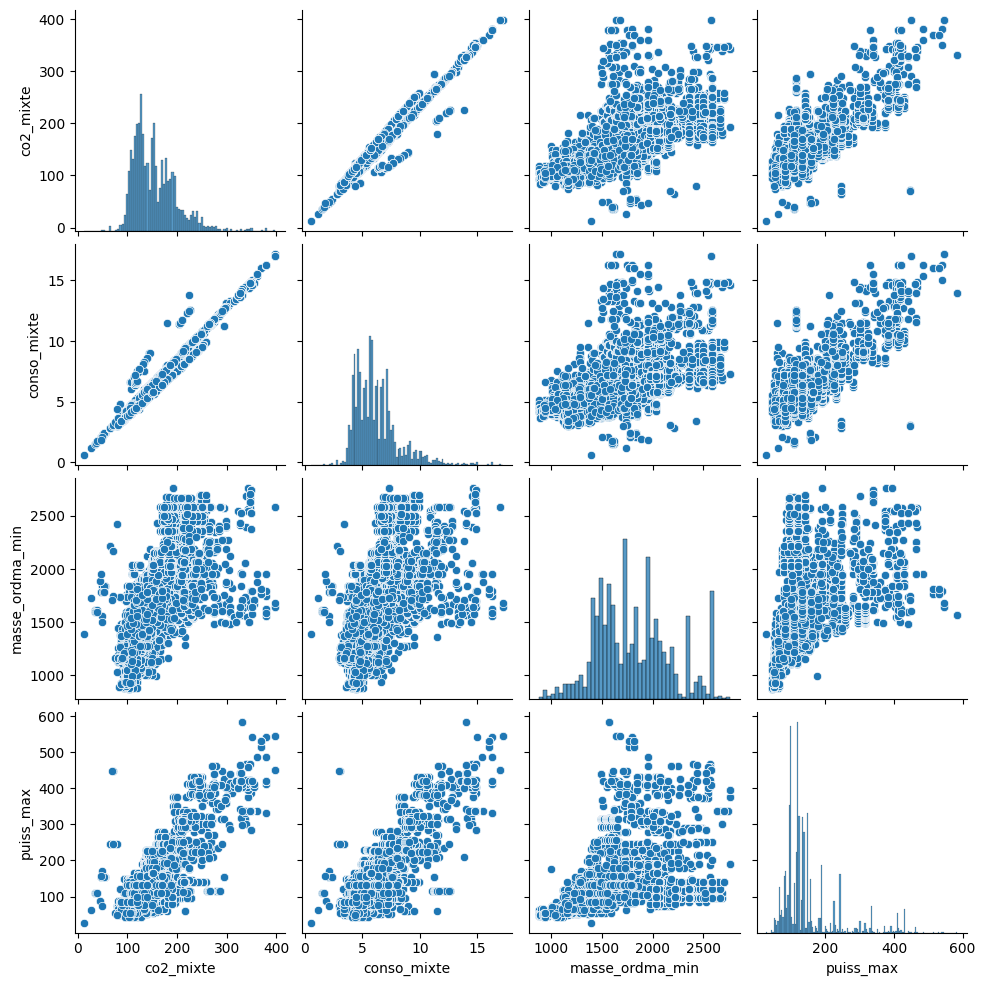

In [66]:
variables_pairplot = [
    'co2_mixte',
    'conso_mixte',
    'masse_ordma_min',
    'puiss_max'
]

sns.pairplot(
    df_2015[variables_pairplot],
    diag_kind="hist"
)

plt.show()

## Interprétation du Pairplot

Le pairplot permet d'examiner simultanément les distributions individuelles des variables ainsi que les relations entre elles.

On observe une relation très forte entre les émissions de CO₂ (`co2_mixte`) et la consommation mixte (`conso_mixte`). Les véhicules qui consomment le plus de carburant sont également ceux qui émettent le plus de CO₂, ce qui confirme les résultats obtenus précédemment avec la matrice de corrélation.

La masse du véhicule (`masse_ordma_min`) présente également une relation positive avec les émissions de CO₂. Les véhicules les plus lourds tendent globalement à être plus polluants, même si une certaine dispersion montre que d'autres facteurs influencent également les émissions.

La puissance maximale du moteur (`puiss_max`) est elle aussi positivement corrélée aux émissions de CO₂. Les véhicules les plus puissants apparaissent généralement parmi les plus émetteurs, ce qui traduit une consommation énergétique plus importante.

Les distributions observées sur la diagonale montrent que certaines catégories de véhicules sont particulièrement représentées dans le dataset, notamment pour les valeurs de consommation, de masse et de puissance les plus fréquentes.

Dans l'ensemble, le pairplot confirme que la consommation, la masse et la puissance du véhicule constituent les principaux facteurs associés aux émissions de CO₂ et apparaissent comme des variables pertinentes pour les futures étapes de modélisation.

## Data visualisation

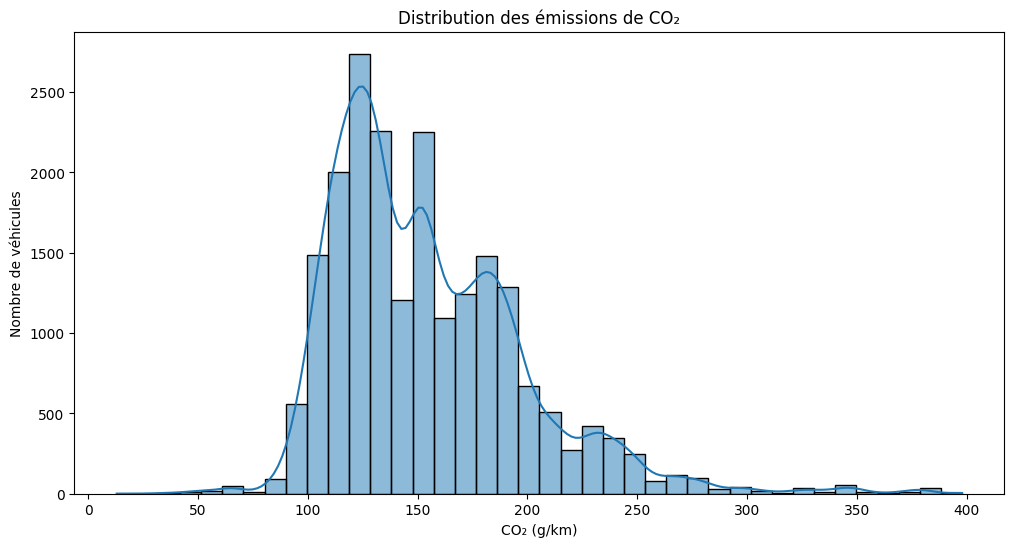

In [ ]:
plt.figure(figsize=(12,6))

sns.histplot(df_2015['co2_mixte'], bins=40, kde=True)

plt.title("Distribution des émissions de CO₂")
plt.xlabel("CO₂ (g/km)")
plt.ylabel("Nombre de véhicules")

plt.show()

## Analyse de la distribution des émissions de CO₂

La distribution des émissions de CO₂ présente une concentration importante des véhicules entre 100 et 200 g/km.

Le pic principal se situe autour de 120 à 150 g/km, ce qui correspond aux niveaux d’émissions les plus fréquents dans le dataset 2015.

La distribution est asymétrique vers la droite, avec quelques véhicules fortement émetteurs dépassant les 300 g/km. Ces valeurs extrêmes correspondent probablement à des véhicules puissants ou à forte consommation.

Globalement, les émissions de CO₂ restent relativement dispersées, traduisant une forte diversité des véhicules commercialisés en France en 2015.

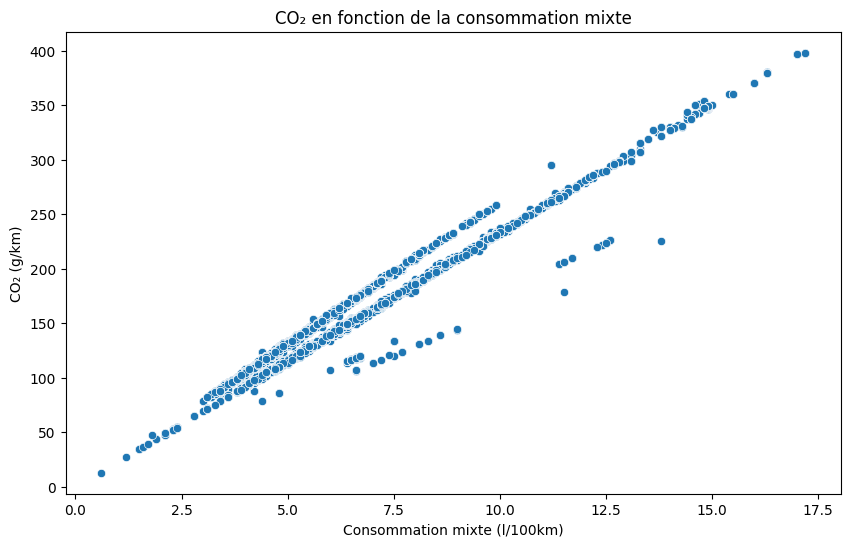

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='conso_mixte',
    y='co2_mixte',
    data=df_2015
)

plt.title("CO₂ en fonction de la consommation mixte")
plt.xlabel("Consommation mixte (l/100km)")
plt.ylabel("CO₂ (g/km)")

plt.show()

## Analyse de la relation entre consommation et émissions de CO₂

Le nuage de points met en évidence une très forte relation positive entre la consommation mixte et les émissions de CO₂.

Plus la consommation de carburant augmente, plus les émissions de CO₂ augmentent de manière quasi linéaire. Les véhicules les plus consommateurs sont également les plus polluants.

La forte concentration des points autour d’une diagonale confirme que la consommation constitue l’un des principaux facteurs explicatifs des émissions de CO₂.

Quelques valeurs atypiques restent visibles, notamment pour certains véhicules fortement consommateurs ou présentant des émissions légèrement différentes pour un même niveau de consommation.

## Validation statistique

In [ ]:
df_2015[['conso_mixte', 'co2_mixte']].corr()

,conso_mixte,co2_mixte
conso_mixte,1.000000,0.976291
co2_mixte,0.976291,1.000000


La corrélation entre la consommation mixte et les émissions de CO₂ est extrêmement élevée (0.98), ce qui confirme quantitativement la relation observée sur le graphique.

Les émissions de CO₂ augmentent presque proportionnellement à la consommation de carburant. La consommation apparaît donc comme le facteur le plus directement lié aux émissions polluantes dans ce jeu de données.

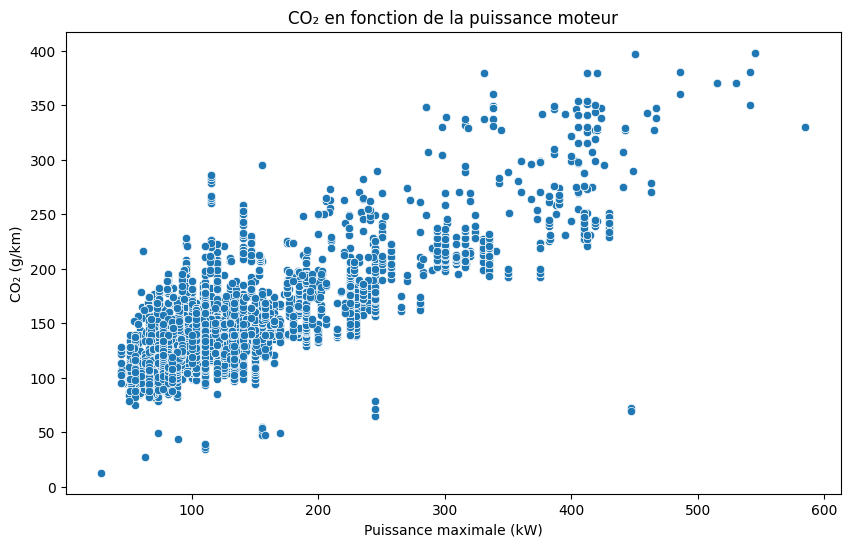

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='puiss_max',
    y='co2_mixte',
    data=df_2015
)

plt.title("CO₂ en fonction de la puissance moteur")
plt.xlabel("Puissance maximale (kW)")
plt.ylabel("CO₂ (g/km)")

plt.show()

## Analyse de la relation entre puissance moteur et émissions de CO₂

Le nuage de points montre une tendance positive entre la puissance maximale du moteur et les émissions de CO₂.

Les véhicules les plus puissants présentent globalement des niveaux d’émissions plus élevés. Cette tendance reste toutefois plus dispersée que celle observée entre la consommation et le CO₂.

Cela signifie que la puissance influence les émissions polluantes, mais qu’elle n’explique pas à elle seule toutes les variations observées. D’autres facteurs, comme le poids du véhicule, le type de carburant ou la consommation, jouent également un rôle important.

Quelques valeurs atypiques apparaissent également, notamment certains véhicules très puissants avec des émissions relativement faibles.

## Validation statistique

In [ ]:
df_2015[['puiss_max', 'co2_mixte']].corr()

,puiss_max,co2_mixte
puiss_max,1.000000,0.646613
co2_mixte,0.646613,1.000000


La corrélation entre la puissance moteur et les émissions de CO₂ est positive et relativement élevée (0.65).

Ce résultat confirme que les véhicules les plus puissants tendent à émettre davantage de CO₂. Toutefois, cette relation reste moins forte que celle observée entre la consommation et les émissions polluantes.

La puissance moteur constitue donc un facteur important des émissions de CO₂, sans être le seul élément explicatif.

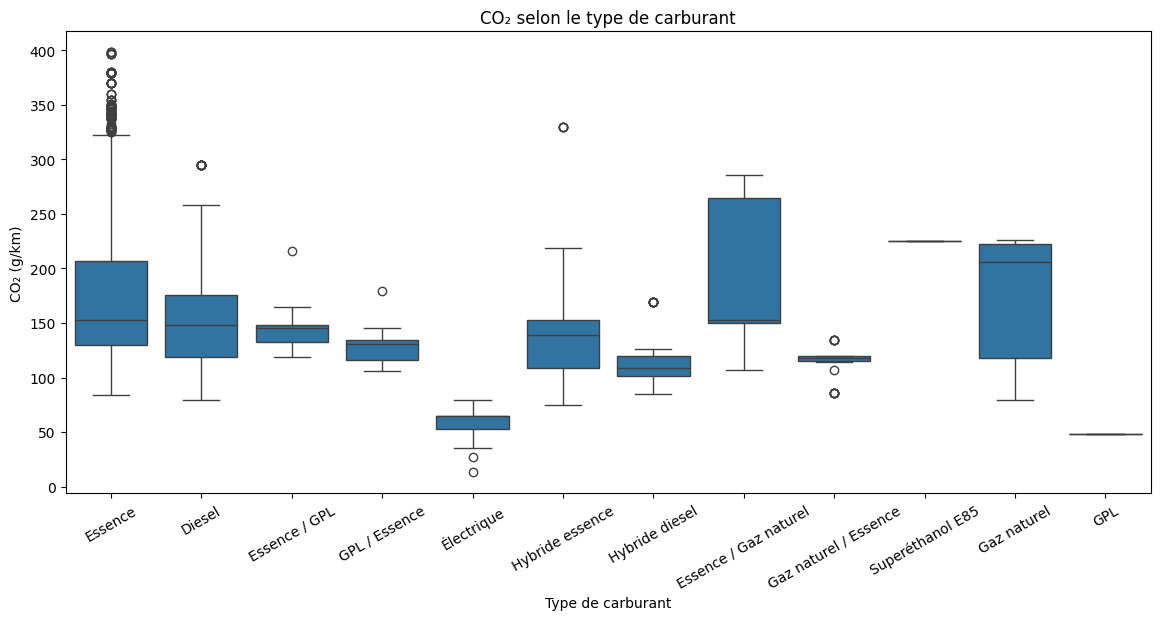

In [78]:
plt.figure(figsize=(14,6))

sns.boxplot(
    x='carburant_libelle',
    y='co2_mixte',
    data=df_2015
)

plt.xticks(rotation=30)

plt.title("CO₂ selon le type de carburant")
plt.xlabel("Type de carburant")
plt.ylabel("CO₂ (g/km)")

plt.show()

## Analyse des émissions de CO₂ selon le type de carburant

Le graphique met en évidence des différences marquées d’émissions de CO₂ selon le type de carburant utilisé.

Les véhicules fonctionnant à l’essence et au diesel présentent les niveaux d’émissions les plus élevés, avec également une forte dispersion des valeurs, traduisant une grande diversité de modèles et de motorisations.

À l’inverse, les véhicules électriques affichent les émissions de CO₂ les plus faibles. Les hybrides essence et hybrides diesel présentent également des niveaux d’émissions inférieurs à ceux des motorisations thermiques traditionnelles.

Les carburants alternatifs tels que le GPL, le gaz naturel ou les combinaisons essence/gaz naturel et GPL/essence montrent des résultats plus variables. Toutefois, leur interprétation doit rester prudente en raison du faible nombre d’observations disponibles dans certaines catégories.

Enfin, la présence de valeurs atypiques dans plusieurs groupes confirme l’hétérogénéité du parc automobile étudié.

Cette analyse confirme que le type de motorisation constitue un facteur important dans l’explication des émissions de CO₂ des véhicules du dataset 2015.

## Information sur la variable carrosserie

Contrairement au dataset 2014, le jeu de données 2015 ne contient plus de variable décrivant la carrosserie des véhicules.

L’analyse des émissions de CO₂ selon le type de carrosserie n’a donc pas pu être reproduite pour cette année.

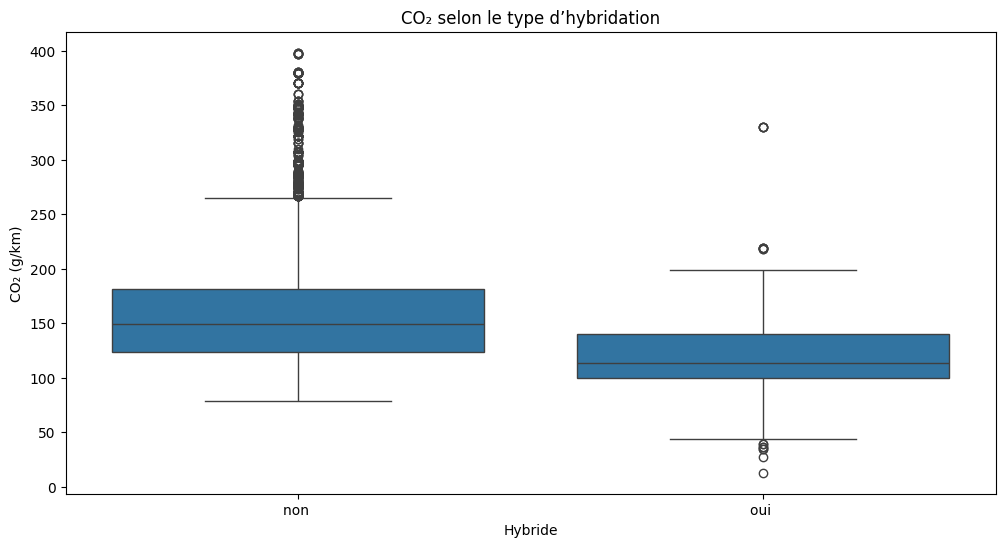

In [79]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x='hybride',
    y='co2_mixte',
    data=df_2015
)

plt.title("CO₂ selon le type d’hybridation")
plt.xlabel("Hybride")
plt.ylabel("CO₂ (g/km)")

plt.show()

## Analyse des émissions de CO₂ selon l’hybridation

Le graphique met en évidence une différence notable entre les véhicules hybrides et non hybrides.

Les véhicules hybrides présentent globalement des émissions de CO₂ plus faibles que les véhicules non hybrides. Leur médiane est inférieure et la dispersion des valeurs reste plus limitée.

À l’inverse, les véhicules non hybrides affichent des émissions plus élevées ainsi qu’une plus grande variabilité, avec plusieurs valeurs extrêmes dépassant 300 g/km.

Cette observation confirme l’impact positif de l’hybridation sur la réduction des émissions polluantes.

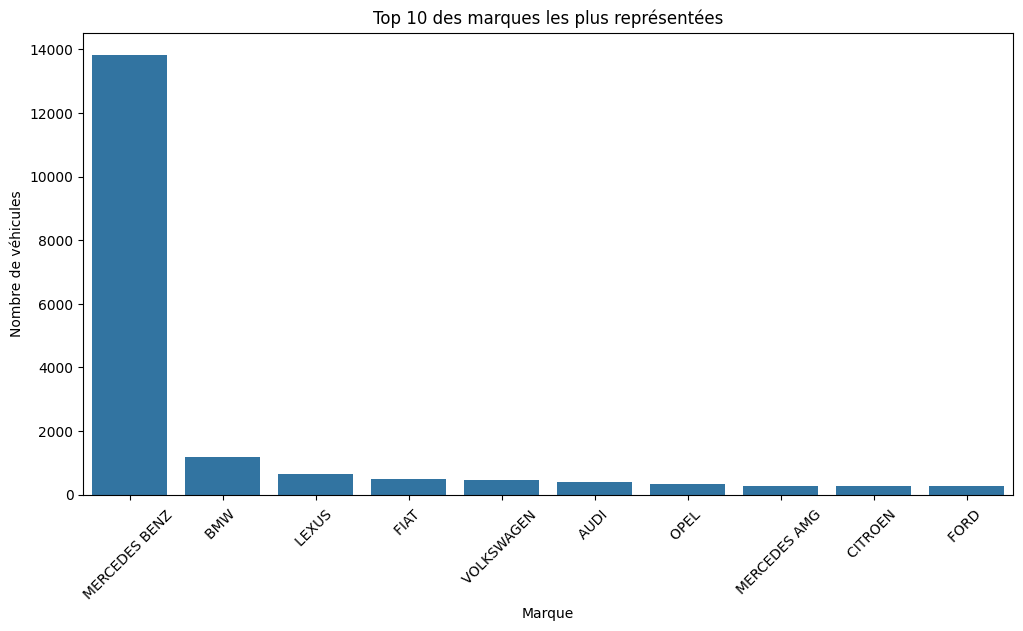

In [80]:
# Top 10 des marques les plus représentées

top_marques_rep = (
    df_2015['lib_mrq_doss']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_marques_rep.index,
    y=top_marques_rep.values
)

plt.xticks(rotation=45)

plt.title("Top 10 des marques les plus représentées")
plt.xlabel("Marque")
plt.ylabel("Nombre de véhicules")

plt.show()

## Analyse des marques les plus représentées

Le graphique met en évidence une très forte concentration du dataset autour de la marque Mercedes-Benz, qui représente à elle seule une part largement majoritaire des véhicules recensés.

Derrière Mercedes-Benz, les marques BMW, Lexus, Fiat, Volkswagen et Audi apparaissent en proportions nettement plus faibles. Les autres constructeurs du Top 10 ne représentent chacun qu'une faible part du jeu de données.

Cette répartition suggère un déséquilibre important dans la représentation des marques au sein du dataset 2015. Les analyses globales pourront donc être davantage influencées par les caractéristiques des véhicules Mercedes-Benz que par celles des autres constructeurs.

Il convient également de rappeler que ce classement reflète la composition du jeu de données et non nécessairement la répartition réelle du marché automobile français.

Enfin, la comparaison avec le classement des marques les plus polluantes permettra de vérifier si les marques les plus représentées sont également celles qui affichent les niveaux moyens d'émissions de CO₂ les plus élevés.

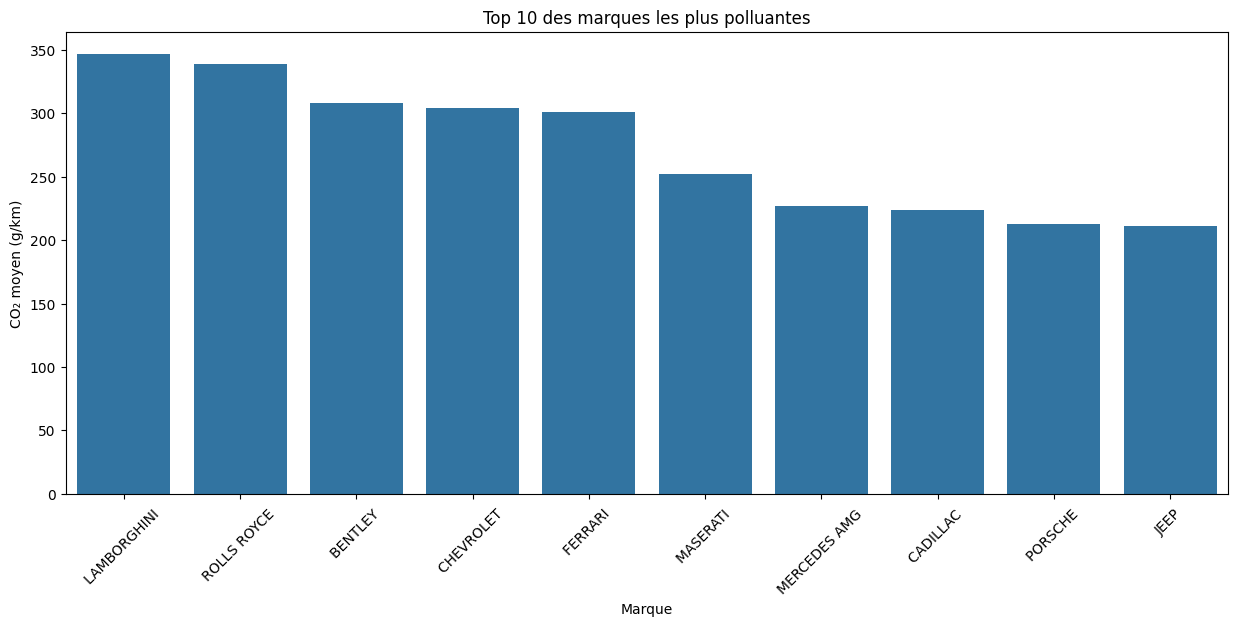

In [81]:
top_marques = (
    df_2015.groupby('lib_mrq_doss')['co2_mixte']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(15,6))

sns.barplot(
    x=top_marques.index,
    y=top_marques.values
)

plt.xticks(rotation=45)

plt.title("Top 10 des marques les plus polluantes")
plt.xlabel("Marque")
plt.ylabel("CO₂ moyen (g/km)")

plt.show()

## Analyse des marques les plus polluantes

Le graphique présente les dix marques affichant les émissions moyennes de CO₂ les plus élevées dans le dataset 2015.

Les premières positions sont occupées par Lamborghini, Rolls-Royce, Bentley, Chevrolet et Ferrari, avec des émissions moyennes supérieures à 300 g/km pour certaines d'entre elles. Ces constructeurs sont principalement associés à des véhicules de forte puissance, sportifs ou haut de gamme.

Les marques Maserati, Mercedes AMG, Cadillac, Porsche et Jeep complètent ce classement avec des niveaux d'émissions également élevés par rapport à la moyenne du dataset.

Ces résultats sont cohérents avec les caractéristiques techniques de ces véhicules, généralement plus puissants, plus lourds et plus consommateurs de carburant que les véhicules de grande diffusion.

Cette analyse met en évidence le lien entre les performances automobiles, la consommation énergétique et le niveau moyen d'émissions de CO₂.

## Comparaison entre présence et niveau d'émissions

Les marques les plus polluantes ne figurent pas parmi les marques les plus représentées du dataset.

À l'inverse, Mercedes-Benz, BMW, Volkswagen ou Audi, qui apparaissent parmi les marques les plus présentes, ne figurent pas en tête du classement des émissions moyennes de CO₂.

Cette différence montre que la représentativité d'une marque dans le jeu de données et son niveau moyen d'émissions constituent deux dimensions distinctes qu'il convient d'analyser séparément.

Les marques les plus polluantes sont souvent spécialisées dans des véhicules de niche ou de prestige, ce qui explique leur faible présence dans le dataset malgré des émissions moyennes particulièrement élevées.

## Chargement des données europe 2014

In [89]:
df_europe_2014 = pd.read_csv(
    "../data/CO2_europe_2014.csv",
    sep="\t"
)

df_europe_2014.head()

/tmp/ipykernel_4056/2385173321.py:1: DtypeWarning: Columns (0: IT) have mixed types. Specify dtype option on import or set low_memory=False.
  df_europe_2014 = pd.read_csv(


,id,MS,MP,Mh,MAN,MMS,TAN,T,Va,Ve,...,w (mm),at1 (mm),at2 (mm),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),IT,Er (g/km)
0,1,AT,na,AA-IVA,AA-IVA,ADAM OPEL AG,27713/2014,K/R,ABAA,ABBAABBAA,...,2415.0,1543.0,1561.0,Petrol,M,1998.0,194.0,NaN,NaN,NaN
1,2,AT,na,AA-IVA,AA-IVA,AUDI AG,12610/2014,4H,NaN,NaN,...,3122.0,1652.0,1643.0,Petrol,M,6299.0,368.0,NaN,NaN,NaN
2,3,AT,na,AA-IVA,AA-IVA,AUDI AG,11723/2014,4L,XBUGQ1,QA69D052R4L907GGS5FS,...,3013.0,1653.0,1695.0,Diesel,M,2967.0,171.0,NaN,NaN,NaN
3,4,AT,na,AA-IVA,AA-IVA,AUDI AG,14593/2014,8K,NaN,NaN,...,2805.0,1583.0,1574.0,Petrol,M,1984.0,220.0,NaN,NaN,NaN
4,5,AT,na,AA-IVA,AA-IVA,AUDI AG,11532/2014,8V,NaN,NaN,...,2594.0,1555.0,1526.0,Petrol,M,1984.0,221.0,NaN,NaN,NaN


Le jeu de données européen 2014 a été importé avec succès. Il contient des informations techniques et environnementales sur plus de 400 000 véhicules immatriculés en Europe.

In [90]:
df_europe_2014.info()

<class 'pandas.DataFrame'>
RangeIndex: 417939 entries, 0 to 417938
Data columns (total 26 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         417939 non-null  int64  
 1   MS         417939 non-null  str    
 2   MP         417939 non-null  str    
 3   Mh         417939 non-null  str    
 4   MAN        417939 non-null  str    
 5   MMS        382750 non-null  str    
 6   TAN        394533 non-null  str    
 7   T          414080 non-null  str    
 8   Va         402134 non-null  str    
 9   Ve         394729 non-null  str    
 10  Mk         396807 non-null  str    
 11  Cn         416504 non-null  str    
 12  Ct         417936 non-null  str    
 13  r          417939 non-null  int64  
 14  e (g/km)   416896 non-null  float64
 15  m (kg)     417647 non-null  float64
 16  w (mm)     397308 non-null  float64
 17  at1 (mm)   395346 non-null  float64
 18  at2 (mm)   382494 non-null  float64
 19  Ft         417804 non-null  str   

Le dataset comprend 417 939 observations et 26 variables. Il contient à la fois des variables numériques (émissions de CO₂, masse, puissance, cylindrée) et des variables catégorielles (carburant, marque, constructeur, pays). Certaines variables présentent des valeurs manquantes qui devront être prises en compte lors des analyses.

## Renommage des variables

In [96]:
df_europe_2014 = df_europe_2014.rename(columns={
    "e (g/km)": "co2",
    "m (kg)": "masse",
    "ep (KW)": "puissance",
    "Ft": "carburant",
    "Mk": "marque",
    "ec (cm3)": "cylindree"
})

Afin de faciliter la lecture et l'interprétation des résultats, les principales variables utilisées dans l'analyse ont été renommées avec des intitulés plus explicites.

## Vérification des variables retenues

In [97]:
df_europe_2014[
    ["co2", "masse", "puissance", "carburant", "marque"]
].head()

,co2,masse,puissance,carburant,marque
0,218.0,1406.0,194.0,Petrol,OPEL
1,264.0,2195.0,368.0,Petrol,AUDI
2,282.0,2370.0,171.0,Diesel,AUDI
3,NaN,1840.0,220.0,Petrol,AUDI
4,165.0,1695.0,221.0,Petrol,AUDI


## Contrôle des valeurs manquantes

In [98]:
df_europe_2014[["co2","masse","puissance","carburant","marque"]].info()

<class 'pandas.DataFrame'>
RangeIndex: 417939 entries, 0 to 417938
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   co2        416896 non-null  float64
 1   masse      417647 non-null  float64
 2   puissance  338040 non-null  float64
 3   carburant  417804 non-null  str    
 4   marque     396807 non-null  str    
dtypes: float64(3), str(2)
memory usage: 15.9 MB


Les variables sélectionnées présentent un faible niveau de valeurs manquantes pour le CO₂, la masse et le carburant. La variable puissance est légèrement moins complète mais reste largement exploitable pour les analyses exploratoires.

## Nettoyage des carburants

In [100]:
df_europe_2014["carburant"] = (
    df_europe_2014["carburant"]
    .str.strip()
    .str.lower()
)

In [101]:
carburants = {
    "diesel": "Diesel",
    "petrol": "Essence",
    "electric": "Électrique",
    "lpg": "GPL",
    "ng-biomethane": "Gaz naturel",
    "e85": "E85",
    "petrol-electric": "Hybride essence",
    "diesel-electric": "Hybride diesel",
    "hydrogen": "Hydrogène",
    "biodiesel": "Biodiesel",
    "petrol-gas": "Essence / Gaz"
}

df_europe_2014["carburant"] = (
    df_europe_2014["carburant"]
    .replace(carburants)
)

Plusieurs modalités de carburant étaient dupliquées en raison de différences d'écriture (majuscules/minuscules). Une harmonisation a été réalisée afin d'obtenir des catégories cohérentes et comparables.

## Vérification après harmonisation

In [102]:
df_europe_2014["carburant"].value_counts()

carburant
Diesel             233879
Essence            176772
GPL                  2393
Gaz naturel          1762
Électrique           1471
Hybride essence      1035
E85                   281
Hybride diesel        202
Hydrogène               4
Biodiesel               4
Essence / Gaz           1
Name: count, dtype: int64

Après harmonisation des libellés, la variable carburant met en évidence une très forte domination des motorisations Diesel et Essence dans le parc automobile européen de 2014. Les véhicules Diesel représentent plus de la moitié des observations, tandis que les véhicules électriques et hybrides demeurent très minoritaires. Cette répartition reflète la structure du marché automobile européen au début des années 2010, avant la forte croissance des motorisations électrifiées observée ces dernières années.

In [103]:
# Statistiques descriptives
df_europe_2014.describe(include='all')

,id,MS,MP,Mh,MAN,MMS,TAN,T,Va,Ve,...,w (mm),at1 (mm),at2 (mm),carburant,Fm,cylindree,puissance,z (Wh/km),IT,Er (g/km)
count,417939.000000,417939,417939,417939,417939,382750,394533,414080,402134,394729,...,397308.000000,395346.000000,382494.000000,417804,413252,415236.000000,338040.000000,1425.000000,41,42.000000
unique,NaN,28,14,103,109,708,10035,2619,12022,24065,...,NaN,NaN,NaN,11,4,NaN,NaN,NaN,7,NaN
top,NaN,DE,VW GROUP PC,VOLKSWAGEN,VOLKSWAGEN AG,VOLKSWAGEN AG,e1*2001/116*0430*33,B8,A,-,...,NaN,NaN,NaN,Diesel,M,NaN,NaN,NaN,e1 3,NaN
freq,NaN,69949,128414,53751,53751,29719,2007,12432,3537,4356,...,NaN,NaN,NaN,233879,408224,NaN,NaN,NaN,28,NaN
mean,208970.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2703.644525,1580.761288,1577.779484,NaN,NaN,1885.718225,117.733200,147.795088,NaN,1.380952
std,120648.741415,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,207.857559,198.005061,202.970453,NaN,NaN,720.643288,62.191607,34.916214,NaN,0.976614
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,500.000000,155.000000,480.000000,NaN,NaN,97.000000,0.000000,12.000000,NaN,0.000000
25%,104485.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2600.000000,1530.000000,1508.000000,NaN,NaN,1461.000000,80.000000,129.000000,NaN,1.200000
50%,208970.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2685.000000,1551.000000,1551.000000,NaN,NaN,1798.000000,103.000000,146.000000,NaN,1.200000
75%,313454.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2810.000000,1585.000000,1586.000000,NaN,NaN,1997.000000,133.000000,165.000000,NaN,1.200000


In [104]:
df_2014.isnull().sum()

lib_mrq                  0
lib_mod_doss             0
lib_mod                  0
dscom                    0
cnit                     0
tvv                      0
cod_cbr                  0
hybride                  0
puiss_admin_98           0
puiss_max              193
typ_boite_nb_rapp        0
conso_urb            48920
conso_exurb          50499
conso_mixte          48548
co2                     34
co_typ_1               158
hc                   54464
nox                  55014
hcnox                55033
ptcl                 36770
masse_ordma_min          0
masse_ordma_max          0
champ_v9                61
date_maj             51797
Carrosserie              0
gamme                    0
carburant_libelle       34
dtype: int64

In [105]:
(df_europe_2014.isnull().mean()*100).sort_values(ascending=False)

IT           99.990190
Er (g/km)    99.989951
z (Wh/km)    99.659041
puissance    19.117383
at2 (mm)      8.480903
MMS           8.419650
TAN           5.600339
Ve            5.553442
at1 (mm)      5.405813
marque        5.056240
w (mm)        4.936366
Va            3.781652
Fm            1.121456
T             0.923340
cylindree     0.646745
Cn            0.343352
co2           0.249558
masse         0.069867
carburant     0.032301
Ct            0.000718
Mh            0.000000
MS            0.000000
id            0.000000
MP            0.000000
MAN           0.000000
r             0.000000
dtype: float64